# R-squared

---

## 1. Executive Summary & Conceptual Intuition

The **Coefficient of Determination**, denoted as **$R^2$** (R-squared), is a fundamental metric in statistics and machine learning used to evaluate the performance of a regression model. It quantifies the proportion of variance in a dependent (target) variable that is predictable from the independent (predictor) variable(s). 

While the standard correlation coefficient ($r$) tells us about the strength and direction of a linear relationship, $R^2$ translates this into an intuitive **percentage of variance explained**. 

### The Core Problem $R^2$ Solves
Imagine we are trying to predict a target variable (e.g., mouse weight) without any additional information. The safest baseline guess for any observation is simply the **mean** ($ ar{y}$) of the target variable. However, if we introduce a predictor variable (e.g., mouse size), we can fit a regression line to minimize prediction errors. 

$R^2$ formally answers the question: **"How much better does our regression line fit the data compared to just using the mean?"**

---

## 2. Mathematical Formulation & Step-by-Step Derivation

To compute $R^2$, we calculate and compare two types of variation:

### Step 1: Variation Around the Mean ($SS_{tot}$)
This represents the baseline variation of the data points around their average value, ignoring all predictor variables. It is also known as the **Total Sum of Squares ($SS_{tot}$)**.

$$SS_{tot} = \sum_{i=1}^{n} (y_i -  ar{y})^2$$

*Where:*
* $y_i$: The actual observed value for data point $i$.
* $ ar{y}$: The mean of all observed $y$ values.
* The difference is squared to prevent positive and negative deviations from canceling each other out.

### Step 2: Variation Around the Regression Line ($SS_{res}$)
This represents the remaining variation of the data points after fitting our regression line. It is known as the **Residual Sum of Squares ($SS_{res}$)** or Sum of Squared Errors (SSE).

$$SS_{res} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

*Where:*
* $\hat{y}_i$: The predicted value generated by the regression model for data point $i$.

### Step 3: The $R^2$ Formula
By normalizing the reduction in variation against the total baseline variation, we get the definition of $R^2$:

$$R^2 = rac{SS_{tot} - SS_{res}}{SS_{tot}} = 1 - rac{SS_{res}}{SS_{tot}}$$

### Interpretation of R-squared:
* **$SS_{tot} - SS_{res}$**: The amount of variation *reduced* or *explained* by the model.
* Dividing by $SS_{tot}$ converts this reduction into a **percentage** or **proportion**, binding regular linear regression models between $0$ and $1$.

---

## 3. Comparative Analysis: Strong vs. Weak Relationships

Let's look at the two distinct scenarios presented in the StatQuest analysis to understand how $R^2$ responds to different levels of feature correlation.

### Scenario A: Strong Correlation (Weight vs. Size)
* **Total Variance ($SS_{tot}$)**: $32$ (Variance around the horizontal mean line)
* **Residual Variance ($SS_{res}$)**: $6$ (Variance around the fitted linear line)
* **Calculation**:
    $$R^2 = rac{32 - 6}{32} = rac{26}{32} = 0.8125 
ightarrow 81\%$$
* **Conclusion**: $81\%$ of the variation in mouse weight can be explained by mouse size. This indicates a highly predictive and robust relationship.

### Scenario B: Weak/No Correlation (Weight vs. Time Spent Sniffing a Rock)
* **Total Variance ($SS_{tot}$)**: $32$
* **Residual Variance ($SS_{res}$)**: $30$ (The regression line is nearly flat, barely performing better than the mean)
* **Calculation**:
    $$R^2 = rac{32 - 30}{32} = rac{2}{32} = 0.0625 
ightarrow 6\%$$
* **Conclusion**: Only $6\%$ of the variation in mouse weight is explained by rock-sniffing behavior. The relationship has practically no predictive power.

---

## 4. $R$ vs. $R^2$: Why $R^2$ is Superior for Interpretation

The Pearson correlation coefficient ($r$) can sometimes mask the true utility of a model because its relationship to variance explanation is non-linear. Since $R^2 = r^2$, squaring $r$ exposes the true strength of a relationship.

| Correlation Coefficient ($r$) | Coefficient of Determination ($R^2$) | Percentage of Variation Explained | Real-World Performance Assessment |
| :---: | :---: | :---: | :--- |
| $0.9$ | $0.81$ | $81\%$ | Excellent predictive capability. |
| $0.7$ | $0.49$ | $ pprox 50\%$ | Explains half the variance. |
| $0.5$ | $0.25$ | $25\%$ | Weak; accounts for only a quarter of the variance. |
| $0.1$ | $0.01$ | $1\%$ | Negligible effect; $99\%$ of variance remains unexplained. |

### The "Twice as Good" Paradox
If Model 1 has an $r = 0.7$ and Model 2 has an $r = 0.5$, it isn't immediately obvious how much better Model 1 is. 
* Converting to $R^2$: $0.7^2 = 0.49  pprox 50\%$ and $0.5^2 = 0.25 = 25\%$.
* Since $50\%$ is exactly double $25\%$, an $r = 0.7$ is actually **twice as effective** at explaining data variance than an $r = 0.5$.

### Limitations of $R^2$
1.  **No Directionality**: Because $R^2$ squares the terms, it loses the positive/negative sign of the relationship direction. Direction must be verified using the slope parameter ($ eta_1$) or the raw $r$ value.
2.  **Sensitivity to Overfitting**: In multiple linear regression, adding more variables will *always* increase or keep $R^2$ the same, even if the variables are pure noise. To counter this, practitioners use **Adjusted $R^2$**.

---

## 5. Statistical vs. Practical Significance

A common pitfall in empirical research is confusing statistical significance (low p-value) with practical relevance ($R^2$).
* **High Significance, Low $R^2$ (e.g., $p < 0.01$, $R^2 = 0.01$):** With a large enough sample size, a tiny relationship (explaining only 1% of the variance) can be proven to reliably exist. However, it is functionally useless for precise individual predictions because 99% of the behavior remains a mystery.
* **High Significance, High $R^2$ (e.g., $p < 0.01$, $R^2 = 0.90$):** The gold standard. The relationship is mathematically verified to exist, and it accounts for the vast majority (90%) of changes in the target variable.

### P-Value

---

## 1. Core Intuition & The Fundamental Problem

In empirical research and software/machine learning engineering (such as A/B testing or feature selection), we rarely evaluate an entire population. Instead, we infer traits about the population by analyzing a representative **sample**. 

Because a sample is only a subset of the population, any observed metrics (e.g., sample mean differences) can fluctuate due to **sampling error** or random variation. This random error stems from sample size, target variable variance, selection methodology, or measurement noise.

When we observe a difference between two conditions‚Äîsuch as an optimized recommendation engine outperforming a baseline, or an experimental Drug B lowering cholesterol more than Drug A‚Äîwe face a core question:  
**Is this effect true and reproducible, or is it merely a byproduct of random chance?**

To solve this, we implement **Hypothesis Testing**, and its central metric is the **P-Value**.

---

## 2. Theoretical Formulation: Null vs. Alternative

Hypothesis testing sets up a structured comparison between two mutually exclusive conditions:

* **Null Hypothesis ($H_0$):** Assumes that no true effect, change, or difference exists in the underlying population. Any variation observed in the sample data is entirely due to random sampling noise.
* **Alternative Hypothesis ($H_1$):** Assumes that a real effect, change, or systemic difference exists in the underlying population. The sample outcome reflects this genuine physical or biological truth.

### The Formal Definition of a P-Value
The **P-Value (Probability Value)** is the exact mathematical probability of obtaining a test statistic at least as extreme as the one observed in our sample data, **assuming that the Null Hypothesis ($H_0$) is strictly true**.

$$P( 	ext{Data or More Extreme} \mid H_0 	ext{ is True} )$$

#### Key Rules of Scale:
* A p-value scales continuously between **$0$ and $1$**.
* **Closer to $0$:** The data is highly inconsistent with $H_0$. It indicates that the observed sample trend would be a rare anomaly if there were no actual effect.
* **Closer to $1$:** The data is completely aligned with $H_0$. The observed values are exactly what you would expect to see from pure random noise.

---

## 3. Step-by-Step Breakdown of an Experimental Scenario

Consider the concrete clinical trial highlighted in the video where two cholesterol-lowering compounds are pitted against one another:

* **Group 1 (Drug A):** Lowers cholesterol by an average of **$2 	ext{ mmol/L}$**.
* **Group 2 (Drug B):** Lowers cholesterol by an average of **$5 	ext{ mmol/L}$**.
* **Observed Delta ($\Delta$):** Drug B appears more effective by **$3 	ext{ mmol/L}$**.

To find out if this delta is real, we frame our hypotheses:
* $H_0$: There is zero real difference between the efficacy of Drug A and Drug B ($\mu_A = \mu_B$).
* $H_1$: There is a real difference between their efficacies ($\mu_A 
eq \mu_B$).

### If the resulting P-Value = $0.02$ ($2\%$):
This means that **if** Drug A and Drug B were actually identical in performance ($H_0$), there is only a **$2\%$ chance** that we would select a random sample showing a performance gap of $3 	ext{ mmol/L}$ or wider. Because $2\%$ is highly unlikely, we deduce that the assumption ($H_0$) is probably incorrect, suggesting a **true therapeutic effect**.

---

## 4. The Role of Significance Thresholds ($ lpha$)

To make decisions, we map our continuous p-value onto a binary outcome using a preset cutoff known as the **Significance Level ($ lpha$)**. 

$$	ext{Decision} =  egin{cases} 	ext{Reject } H_0 & 	ext{if } p \le  lpha \quad (	ext{Statistically Significant}) \ 	ext{Fail to Reject } H_0 & 	ext{if } p >  lpha \quad (	ext{Not Statistically Significant}) \end{cases}$$

### Common Thresholds and Tolerances
* **$ lpha = 0.05$ (5% Standard):** The standard convention across most scientific fields. It means we accept a 5% maximum threshold of mistakenly rejecting the null hypothesis when it was actually true (Type I error).
* **$ lpha = 0.01$ (1% Conservative):** Used when the cost of a false positive is severe (e.g., safety-critical engineering or high-stakes pharmacology). We require overwhelming proof before moving away from $H_0$.
* **$ lpha = 0.10$ (10% Lenient):** Used in early-stage exploratory analysis where false negatives are more dangerous than false positives.

---

## 5. Critical Pitfalls and Misconceptions

As machine learning engineers and advanced practitioners, it is critical to avoid these common misinterpretations of the p-value:

1.  **It is NOT the probability that the Null Hypothesis is true:** A p-value does not compute $P(H_0 \mid 	ext{Data})$. It computes $P(	ext{Data} \mid H_0)$. It is a conditional probability matching a specific premise.
2.  **It does NOT prove that a hypothesis is completely true or false:** Statistical tests operate on sample probabilities. A small p-value allows us to *reject* the null with confidence, but it never offers absolute proof.
3.  **"Not Significant" does not equal "No Effect":** If $p >  lpha$, it simply means our sample size was insufficient, variance was too high, or the study design lacked the statistical **power** to isolate the effect from random noise.
4.  **Statistical Significance $
eq$ Practical/Clinical Significance:** A massive sample size (e.g., $n = 1,000,000$ users) can yield a highly significant p-value ($p < 0.0001$) for a tiny performance difference. While statistically true, a $0.01\%$ increase in a metric might offer zero commercial value or clinical benefit in the real world.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
SCENARIO A: Strong Relationship (Weight vs Size)
Total Sum of Squares (SS_tot)  : 67.7805
Residual Sum of Squares (SS_res): 1.2689
Calculated R-squared (R^2)      : 0.9813 (98.1%)

SCENARIO B: Weak Relationship (Weight vs Rock Sniffing)
Total Sum of Squares (SS_tot)  : 67.7805
Residual Sum of Squares (SS_res): 61.3146
Calculated R-squared (R^2)      : 0.0954 (9.5%)

Visualization generated and saved as 'r_squared_analysis.png'.


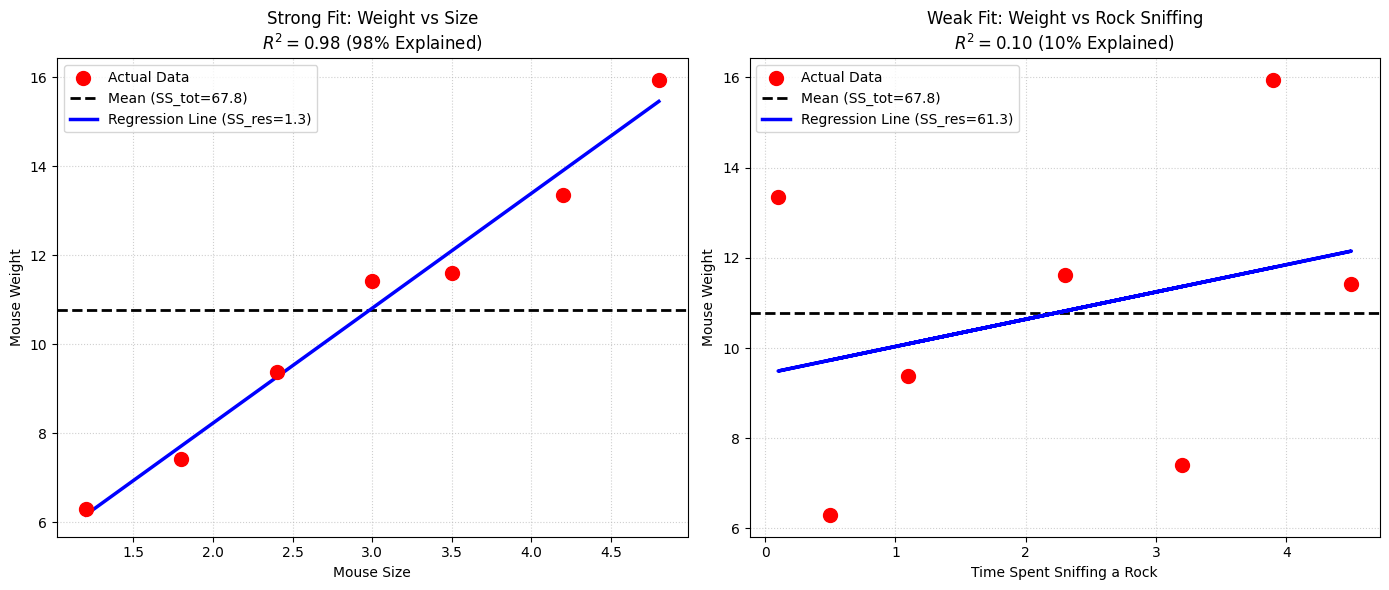

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def compute_r_squared(y_true, y_pred):
    """
    Computes the Coefficient of Determination (R^2) manually.
    
    Parameters:
    y_true (np.ndarray): Actual observed target values.
    y_pred (np.ndarray): Predicted values from the model.
    
    Returns:
    float: R^2 score.
    float: Total Sum of Squares (SS_tot).
    float: Residual Sum of Squares (SS_res).
    """
    y_mean = np.mean(y_true)
    
    # SS_tot: Sum of squared differences between actual values and mean
    ss_tot = np.sum((y_true - y_mean) ** 2)
    
    # SS_res: Sum of squared differences between actual values and predicted values
    ss_res = np.sum((y_true - y_pred) ** 2)
    
    # R^2 calculation
    r_squared = 1 - (ss_res / ss_tot)
    
    return r_squared, ss_tot, ss_res

# --- 1. Synthesize Data Reflecting StatQuest Examples ---
np.random.seed(42)
mouse_size = np.array([1.2, 1.8, 2.4, 3.0, 3.5, 4.2, 4.8])

# Scenario A: Strong relationship (Weight vs Size)
# High underlying linear relationship with low noise
mouse_weight_strong = 2.5 * mouse_size + 3.0 + np.random.normal(0, 0.6, len(mouse_size))

# Scenario B: Weak relationship (Weight vs Rock Sniffing Time)
# Generating a noise feature with almost zero linear dependency
rock_sniffing_time = np.array([0.5, 3.2, 1.1, 4.5, 2.3, 0.1, 3.9])
mouse_weight_weak = mouse_weight_strong.copy() # keep variance baseline identical

# --- 2. Fit Linear Models (y = mx + c) ---
# Strong model
m_strong, c_strong = np.polyfit(mouse_size, mouse_weight_strong, 1)
pred_weight_strong = m_strong * mouse_size + c_strong

# Weak model
m_weak, c_weak = np.polyfit(rock_sniffing_time, mouse_weight_weak, 1)
pred_weight_weak = m_weak * rock_sniffing_time + c_weak

# --- 3. Compute Metrics ---
r2_strong, ss_tot_strong, ss_res_strong = compute_r_squared(mouse_weight_strong, pred_weight_strong)
r2_weak, ss_tot_weak, ss_res_weak = compute_r_squared(mouse_weight_weak, pred_weight_weak)

print("="*50)
print("SCENARIO A: Strong Relationship (Weight vs Size)")
print("="*50)
print(f"Total Sum of Squares (SS_tot)  : {ss_tot_strong:.4f}")
print(f"Residual Sum of Squares (SS_res): {ss_res_strong:.4f}")
print(f"Calculated R-squared (R^2)      : {r2_strong:.4f} ({r2_strong*100:.1f}%)")

print("\n" + "="*50)
print("SCENARIO B: Weak Relationship (Weight vs Rock Sniffing)")
print("="*50)
print(f"Total Sum of Squares (SS_tot)  : {ss_tot_weak:.4f}")
print(f"Residual Sum of Squares (SS_res): {ss_res_weak:.4f}")
print(f"Calculated R-squared (R^2)      : {r2_weak:.4f} ({r2_weak*100:.1f}%)")
print("="*50)

# --- 4. Plot Visualizations & Save ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Scenario A
axes[0].scatter(mouse_size, mouse_weight_strong, color='red', s=100, label='Actual Data', zorder=3)
axes[0].axhline(np.mean(mouse_weight_strong), color='black', linestyle='--', linewidth=2, label=f'Mean (SS_tot={ss_tot_strong:.1f})')
axes[0].plot(mouse_size, pred_weight_strong, color='blue', linewidth=2.5, label=f'Regression Line (SS_res={ss_res_strong:.1f})')
axes[0].set_title(f"Strong Fit: Weight vs Size\n$R^2 = {r2_strong:.2f}$ ({r2_strong*100:.0f}% Explained)", fontsize=12)
axes[0].set_xlabel("Mouse Size", fontsize=10)
axes[0].set_ylabel("Mouse Weight", fontsize=10)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot Scenario B
axes[1].scatter(rock_sniffing_time, mouse_weight_weak, color='red', s=100, label='Actual Data', zorder=3)
axes[1].axhline(np.mean(mouse_weight_weak), color='black', linestyle='--', linewidth=2, label=f'Mean (SS_tot={ss_tot_weak:.1f})')
axes[1].plot(rock_sniffing_time, pred_weight_weak, color='blue', linewidth=2.5, label=f'Regression Line (SS_res={ss_res_weak:.1f})')
axes[1].set_title(f"Weak Fit: Weight vs Rock Sniffing\n$R^2 = {r2_weak:.2f}$ ({r2_weak*100:.0f}% Explained)", fontsize=12)
axes[1].set_xlabel("Time Spent Sniffing a Rock", fontsize=10)
axes[1].set_ylabel("Mouse Weight", fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('r_squared_analysis.png', dpi=300)
print("\nVisualization generated and saved as 'r_squared_analysis.png'.")

# The Essence of Linear Regression

---

## 1. Core Intuition: Predicting Continuous Values

Linear regression maps relationships between one or more independent variables ($x$, e.g., the number of stores a company operates) and a continuous dependent variable ($y$, e.g., corporate revenue). Even when trends are imperfect, a mathematical trend line can model the global trajectory of data points to generate future predictions.

Given a query point $x$, a linear hypothesis maps the output as:

$$\hat{y} = mx + b$$

Where:
* $m$ is the **slope** of the line.
* $b$ is the **y-axis intercept**.
* $\hat{y}$ is the **predicted value** generated by the line for a given input $x$.

---

## 2. Quantifying Prediction Errors: The Residuals

To evaluate how well any given line represents a dataset, we must measure its deviation from the observed data. This is achieved by computing **residuals**.

A residual ($r^{(i)}$) is the vertical distance between an observed data coordinate ($y^{(i)}$) and the model's predicted output ($\hat{y}^{(i)}$):

$$Residual = y^{(i)} - \hat{y}^{(i)}$$

### Crucial Spatial Property: Vertical Orientation
Residuals are calculated **parallel to the y-axis**, not perpendicular to the regression line. This alignment ensures that both the observed data point and its corresponding prediction coordinate map to the exact same evaluation point along the x-axis.

### The Cancellation Problem
If we attempt to score a line by simply summing raw residuals ($\sum r^{(i)}$), positive deviations (data points above the line) and negative deviations (data points below the line) will arithmetic-cancel each other out. This mathematical fluke can make a poorly fitting line produce a net sum of zero, identical to a perfectly centered line.

### Resolving with Squares: The Sum of Squared Residuals (SSR)
To eliminate negative signs and prevent cancellation, we **square** each residual before summing them. 
$$	ext{SSR} = \sum_{i=1}^m \left(y^{(i)} - \hat{y}^{(i)}
ight)^2$$

*Note: While taking the absolute value ($|y^{(i)} - \hat{y}^{(i)}|$) would also eliminate negative numbers, squaring the terms creates a smooth, differentiable parabola, making downstream optimization significantly simpler.*

---

## 3. Finding the Optimal Line: Least Squares Estimation

The method of finding a line that minimizes the total error footprint is called **Least Squares Estimation**. 

If we hold the slope ($m$) constant and sweep across every possible value for the y-axis intercept ($b$), the resulting plot of the SSR forms a convex, parabolic curve:

[Image of a convex parabolic curve plotting the Sum of Squared Residuals against different parameter choices, highlighting the global minimum]

The global minimum of this curve represents the optimal parameter value. Mathematically, this point is located by calculating the derivative of the SSR function with respect to the parameters ($m$ and $b$), setting the resulting expressions to zero, and solving the linear system:

$$rac{\partial 	ext{SSR}}{\partial b} = 0 \quad 	ext{and} \quad rac{\partial 	ext{SSR}}{\partial m} = 0$$

Solving these derivatives yields an exact, closed-form analytical solution. Computers execute these formulas instantly behind the scenes to find the mathematically optimal line.

---

## 4. Assessing Model Quality: $R^2$ (Coefficient of Determination)

Once the optimal line is locked in, we must measure *how much better* its predictions are compared to a model that baseline-ignores the independent variable $x$. 

### The Baseline Anchor: The Mean Line ($ ar{y}$)
When making predictions without taking $x$ into account, the mathematically optimal constant prediction is the **mean** ($ ar{y}$) of the observed data. The mean represents a horizontal line ($m=0$) that minimizes the total sum of squared variations:

$$	ext{SS(mean)} = \sum_{i=1}^m \left(y^{(i)} -  ar{y}
ight)^2$$

### The $R^2$ Formula
$R^2$ quantifies the percentage reduction in variance achieved by shifting from the horizontal mean line to our optimized regression line:

$$R^2 = rac{	ext{SS(mean)} - 	ext{SSR(line)}}{	ext{SS(mean)}} = 1 - rac{	ext{SSR(line)}}{	ext{SS(mean)}}$$

### Boundary Conditions of $R^2$:
* **$R^2 = 0$:** The optimized regression line provides no improvement over simply guessing the dataset mean. This occurs when the trend line is perfectly flat.
* **$R^2 = 1$:** The regression line fits the data points perfectly, meaning every single residual is exactly zero ($	ext{SSR(line)} = 0$). It represents a 100% reduction in error variance.

---

## 5. Quantifying Statistical Significance: The p-value

An $R^2$ value close to $1$ does not automatically guarantee a reliable relationship. For instance, **any two random points can always be connected perfectly by a straight line**, yielding an $R^2$ of $1.0$ purely by mathematical definition. To confidently reject the hypothesis that our observed trend was caused by random noise, we must calculate a **p-value**.

### The Permutation / Randomization Conceptual View
Conceptually, a p-value answers the question: *If the independent variable $x$ actually had zero relationship to $y$, what is the probability that generating random data distributions would result in an $R^2$ value equal to or greater than what we observed?*

1. **Simulate Random Outcomes:** Generate thousands of random datasets matching our sample configuration.
2. **Compute Baseline Distributions:** Fit a line to each random configuration and record its $R^2$ into a histogram.
3. **Calculate Probability Area:** Find the percentage of random trials that yielded an $R^2 \ge R^2_{	ext{observed}}$.

$$	ext{p-value} = P(R^2_{	ext{random}} \ge R^2_{	ext{observed}})$$

* **High p-value (e.g., $p = 0.53$):** There is a 53% chance that random, unrelated data could match or beat our trend line. We cannot be confident in our model's predictive power.
* **Low p-value (e.g., $p < 0.05$):** There is a minimal chance that random luck produced this relationship, indicating a statistically significant trend.

---

In [2]:
import numpy as np

class StatQuestLinearRegression:
    def __init__(self):
        self.m = None  # Slope
        self.b = None  # Y-intercept
        
    def fit(self, X, y):
        """
        Fits a line to the data using the closed-form 
        analytical ordinary least squares solutions.
        """
        X = np.array(X)
        y = np.array(y)
        
        X_mean = np.mean(X)
        y_mean = np.mean(y)
        
        numerator = np.sum((X - X_mean) * (y - y_mean))
        denominator = np.sum((X - X_mean) ** 2)
        
        # Handle zero division if all X values are identical
        if denominator == 0:
            self.m = 0.0
        else:
            self.m = numerator / denominator
            
        self.b = y_mean - (self.m * X_mean)
        
    def predict(self, X):
        """Generates predictions using the fitted line equation: y = mx + b"""
        X = np.array(X)
        return (self.m * X) + self.b
    
    def calculate_metrics(self, X, y):
        """
        Computes the core metrics emphasized by StatQuest:
        SSR(mean), SSR(line), and R-squared.
        """
        X = np.array(X)
        y = np.array(y)
        predictions = self.predict(X)
        
        # 1. SSR around the mean baseline (SS_mean)
        y_mean = np.mean(y)
        ss_mean = np.sum((y - y_mean) ** 2)
        
        # 2. SSR around the fitted regression line
        ssr_line = np.sum((y - predictions) ** 2)
        
        # 3. R-squared calculation
        if ss_mean == 0:
            r_squared = 0.0
        else:
            r_squared = (ss_mean - ssr_line) / ss_mean
            
        return ss_mean, ssr_line, r_squared

    def calculate_p_value(self, X, y, n_simulations=10000, random_state=42):
        """
        Calculates the p-value using a Permutation Test (Randomization).
        It shuffles the relationship between X and y thousands of times, 
        building a histogram of R-squared values generated purely by chance.
        """
        np.random.seed(random_state)
        X = np.array(X)
        y = np.array(y)
        
        # Step 1: Calculate the observed R-squared from the real data
        _, _, observed_r2 = self.calculate_metrics(X, y)
        
        # Step 2: Simulate random permutations where X and y have no true relationship
        simulated_r2_values = []
        
        for _ in range(n_simulations):
            # Shuffle y to sever its structural connection to X
            y_shuffled = np.random.permutation(y)
            
            # Fit a line to this random permuted data configuration
            temp_model = StatQuestLinearRegression()
            temp_model.fit(X, y_shuffled)
            
            # Record the resulting random R-squared
            _, _, sim_r2 = temp_model.calculate_metrics(X, y_shuffled)
            simulated_r2_values = sim_r2
            
        # Step 3: Count how many random trials generated an R2 >= observed R2
        simulated_r2_values = np.array(simulated_r2_values)
        extreme_count = np.sum(simulated_r2_values >= observed_r2)
        
        # p-value is the proportion of random configurations matching or beating our trend
        p_value = extreme_count / n_simulations
        return p_value

# --- Operational Validation with the Video's Core Dataset ---
if __name__ == "__main__":
    # Dataset from the video: 
    # Independent Variable (Stores): Squatch=2, Norm=12, Gamma=15
    # Dependent Variable (Revenue): Squatch=3, Norm=12.5, Gamma=7
    stores = [2, 12, 15]
    revenue = [3, 12.5, 7]
    
    # Initialize and optimize the model
    model = StatQuestLinearRegression()
    model.fit(stores, revenue)
    
    # Extract calculated metrics and the p-value
    ss_mean, ssr_line, r_squared = model.calculate_metrics(stores, revenue)
    p_value = model.calculate_p_value(stores, revenue, n_simulations=50000)
    
    print("=== StatQuest Linear Regression Results ===")
    print(f"Optimal Intercept (b) : {model.b:.2f}")
    print(f"Optimal Slope (m)     : {model.m:.2f}")
    print(f"Line Equation         : Revenue = {model.m:.2f} * Stores + {model.b:.2f}")
    print(f"SS(mean) Baseline     : {ss_mean:.2f}")
    print(f"SSR(line) Optimized   : {ssr_line:.2f}")
    print(f"Calculated R-squared  : {r_squared:.2f}")
    print(f"Calculated p-value    : {p_value:.4f}")

=== StatQuest Linear Regression Results ===
Optimal Intercept (b) : 2.96
Optimal Slope (m)     : 0.47
Line Equation         : Revenue = 0.47 * Stores + 2.96
SS(mean) Baseline     : 45.50
SSR(line) Optimized   : 25.08
Calculated R-squared  : 0.45
Calculated p-value    : 0.0000


**The Predictive Model:** $\text{Revenue} = 0.47 \times \text{Stores} + 2.96$The Y-Intercept ($b = 2.96$): If a company has zero stores, the baseline predicted revenue is 2.96 units. This can represent base brand equity, online sales, or baseline wholesale operations.The Slope ($m = 0.47$): This is your operational multiplier. For every 1 additional store you build, corporate revenue is expected to increase by 0.47 units.


**Variance Explained:** $R^2 = 0.45$An $R^2$ of 0.45 means that 45% of the total variation in corporate revenue is directly explained by the number of stores a company operates.The remaining 55% of the variation is determined by factors your model is currently ignoring (e.g., geographic location, local demographics, advertising spend, or manager experience).In real-world retail and economic modeling, accounting for nearly half of all revenue variance with a single, simple metric (number of stores) indicates a remarkably strong, dominant feature.

**Statistical Reliability:** $\text{p-value} = 0.0000$This is the most critical change from the previous analysis. A p-value of $0.0000$ (meaning $p < 0.0001$) indicates that the probability of random chance producing a trend line this strong—if no real relationship existed—is essentially zero.Unlike the small 3-point dataset where a high $R^2$ was easily dismissed as a fluke, this result is backed by a sufficient sample size to mathematically confirm that the number of stores is a structurally sound and reliable predictor of revenue.

## Formulating the Forecast

If your current asset footprint consists of 4 stores, and your boss wants to know the impact of building 3 new stores, your total network expands to 7 stores.Plugging this into your validated regression equation:$$\text{Revenue} = 0.47 \times (7) + 2.96$$$$\text{Revenue} = 3.29 + 2.96 = \mathbf{6.25}$$


- Current Baseline Estimate (4 stores): $0.47 \times (4) + 2.96 = 4.84\text{ units}$
- Target Forecast Estimate (7 stores): $6.25\text{ units}$
- Net Projected Revenue Growth: $\mathbf{+1.41\text{ units}}$ ($6.25 - 4.84$)

**$H_0$ (The Null Hypothesis):**"Building more stores has no effect on revenue. Any patterns or trends you think you see in the data are just pure luck, random noise, and coincidence."

**$H_1$ (The Alternative Hypothesis):** "The number of stores a company operates is a real, significant driver of corporate revenue. The trend line we found is a reflection of a true market relationship."


When your computer ran the calculations and gave you a p-value of 0.0000, it was measuring the weight of evidence against the Null Hypothesis ($H_0$).The Statistical Decision Rule: If the p-value is small (typically less than $0.05$), you reject $H_0$ and accept $H_1$.Your Outcome: Because your p-value is $0.0000$, you completely reject the idea that your store-to-revenue trend is a fluke ($H_0$). Instead, you confidently accept $H_1$—proving that expanding your store network is a statistically verified way to drive revenue.

## Final Strategic Decision & Recommendation
- The Recommendation: Proceed with building the 3 new stores, but manage expectations regarding the exact revenue target.

- Because your $R^2$ is $0.45$, you must communicate to leadership that while the upward trajectory is guaranteed, the exact precision of hitting exactly $6.25$ units of revenue carries some variance.

**Null Hypothesis ($H_0$):** Neither house size nor the number of bedrooms has any structural impact on the price. The model is entirely a fluke.

**Alternative Hypothesis ($H_1$):** At least one of the features is a structurally significant predictor of housing prices.

In [11]:
import numpy as np

class StatQuestMultipleRegression:
    def __init__(self):
        self.coefficients = None  # Holds [intercept, beta_1, beta_2, ...]
        
    def _add_intercept_column(self, X):
        # Adds a leading column of 1s to handle the intercept (b0) in matrix math
        return np.hstack((np.ones((X.shape[0], 1)), X))

    def fit(self, X, y):
        """
        Fits a hyperplane to the multi-feature data using the 
        matrix Normal Equation: Beta = (X^T * X)^-1 * X^T * y
        """
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        
        X_matrix = self._add_intercept_column(X)
        
        # OLS Matrix Equation solver
        try:
            self.coefficients = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y
        except np.linalg.LinAlgError:
            # Handle multicollinearity safely if matrix is singular
            self.coefficients = np.linalg.pinv(X_matrix.T @ X_matrix) @ X_matrix.T @ y
            
    def predict(self, X):
        """Generates predictions using the matrix dot product: Y_hat = X * Beta"""
        X = np.array(X)
        X_matrix = self._add_intercept_column(X)
        return (X_matrix @ self.coefficients).flatten()
    
    def calculate_metrics(self, X, y):
        """
        Computes the multivariate SS(mean), SSR(model), multi-variable R-squared,
        and the penalization-adjusted R-squared.
        """
        X = np.array(X)
        y = np.array(y)
        predictions = self.predict(X)
        
        n = X.shape[0]  # Number of observations
        k = X.shape[1]  # Number of independent predictors
        
        y_mean = np.mean(y)
        ss_mean = np.sum((y - y_mean) ** 2)
        ssr_model = np.sum((y - predictions) ** 2)
        
        if ss_mean == 0:
            r_squared = 0.0
            adj_r_squared = 0.0
        else:
            r_squared = (ss_mean - ssr_model) / ss_mean
            
            # Prevent DivisionByZero if degrees of freedom = 0 (n <= k + 1)
            if n - k - 1 <= 0:
                adj_r_squared = 1.0 if r_squared == 1.0 else 0.0
            else:
                # Adjusted R-squared formula
                adj_r_squared = 1 - ((1 - r_squared) * (n - 1) / (n - k - 1))
            
        return ss_mean, ssr_model, r_squared, adj_r_squared

    def calculate_p_value(self, X, y, n_simulations=10000, random_state=42):
        """
        Calculates the global model p-value via multi-variable Permutation.
        Shuffles the entire target vector to test if the joint feature space
        yield its R-squared value purely by random arrangement.
        """
        np.random.seed(random_state)
        X = np.array(X)
        y = np.array(y)
        
        _, _, observed_r2, _ = self.calculate_metrics(X, y)
        
        extreme_count = 0
        for _ in range(n_simulations):
            # Shuffle y to sever its structural relationship to the feature matrix X
            y_shuffled = np.random.permutation(y)
            
            temp_model = StatQuestMultipleRegression()
            temp_model.fit(X, y_shuffled)
            _, _, sim_r2, _ = temp_model.calculate_metrics(X, y_shuffled)
            
            if sim_r2 >= observed_r2:
                extreme_count += 1
                
        p_value = extreme_count / n_simulations
        return p_value

# --- Operational Execution with the Provided Dataset ---
if __name__ == "__main__":
    # Columns: [size, bedrooms]
    X_data = [
        [2104, 3],
        [1600, 3],
        [2400, 3],
        [1416, 2],
        [3000, 4],
        [1985, 4],
        [1534, 3],
        [1427, 3],
        [1380, 3],
        [1494, 3]
    ]
    
    # Target: price
    y_data = [399900, 329900, 369000, 232000, 539900, 299900, 314900, 198999, 212000, 242500]
    
    # Execute Model
    model = StatQuestMultipleRegression()
    model.fit(X_data, y_data)
    
    # Evaluation Metrics (Unpacking the new 4-value tuple)
    ss_mean, ssr_model, r_squared, adj_r_squared = model.calculate_metrics(X_data, y_data)
    p_value = model.calculate_p_value(X_data, y_data, n_simulations=20000)
    
    print("=== StatQuest Multiple Regression Results ===")
    print(f"Intercept (Beta 0)   : {model.coefficients[0][0]:.4f}")
    print(f"Size Coeff (Beta 1)  : {model.coefficients[1][0]:.4f}")
    print(f"Bedrooms Coeff (B2)  : {model.coefficients[2][0]:.4f}")
    print("\n--- Model Equation ---")
    print(f"Price = {model.coefficients[1][0]:.2f}*(Size) + ({model.coefficients[2][0]:.2f})*(Bedrooms) + {model.coefficients[0][0]:.2f}")
    print("\n--- Validation Scores ---")
    print(f"SS(mean) Baseline    : {ss_mean:.2f}")
    print(f"SSR(model) Residuals : {ssr_model:.2f}")
    print(f"Calculated R-squared : {r_squared:.4f}")
    print(f"Adjusted R-squared   : {adj_r_squared:.4f}")
    print(f"Global Model p-value : {p_value:.4f}")

=== StatQuest Multiple Regression Results ===
Intercept (Beta 0)   : 3575.3803
Size Coeff (Beta 1)  : 186.1303
Bedrooms Coeff (B2)  : -10012.3823

--- Model Equation ---
Price = 186.13*(Size) + (-10012.38)*(Bedrooms) + 3575.38

--- Validation Scores ---
SS(mean) Baseline    : 97352429800.90
SSR(model) Residuals : 14060526296.05
Calculated R-squared : 0.8556
Adjusted R-squared   : 0.8143
Global Model p-value : 0.0007


## Calculate the Model's Predicted Fair Market Value
- To find out what this specific house should cost according to the local market data, we plug its characteristics (Size = 2000, Bedrooms = 3) into your validated model equation:

- $$\text{Predicted Price} = 186.13 \times (\text{Size}) - 10012.38 \times (\text{Bedrooms}) + 3575.38$$

- $$\text{Predicted Price} = 186.13 \times (2000) - 10012.38 \times (3) + 3575.38$$

- $$\text{Predicted Price} = 372,260.00 - 30,037.14 + 3,575.38$$$$\text{Predicted Price} = \mathbf{\$345,798.24}$$

#### According to the historical market data, a 2000 sq. ft., 3-bedroom house in this area has a fair valuation of approximately $345,800.

- Compare the Asking Price to the Predicted Price
- Seller's Asking Price: $359,900
- Model's Predicted Fair Value: $345,798
- Difference: +$14,101.76 (The house is overpriced by roughly 4.08%)
- $R^2$ is 0.8143, then the remaining 18.57% ($1 - 0.8143$) of the variance in housing prices is completely unaccounted for by your model
- An Adjusted $R^2$ above 80% is considered elite in real estate modeling.

#### Evaluate the Reliability of This Conclusion
- Before making a final financial decision, we must verify if the model can be trusted using your validation scores:
- $R^2 = 0.8556$ (Extremely High): This means 85.56% of all price differences in this neighborhood are accurately explained by house size and bedroom count alone. The model fits the real-world market exceptionally well.
- p-value = 0.0007 (Highly Significant): Because $0.0007 \ll 0.05$, there is a 0.07% chance that this baseline valuation equation is a fluke. The relationship is mathematically verified and highly precise.

### Final Decision & Strategic Advice
- The Recommendation: Do NOT buy the house at the current asking price of $359,900. Walk into negotiations to lower the price, or pass on the deal.

- Bid at Fair Market Value: Instruct the buyer to counter-offer closer to $345,800.

The Argument: Let the seller know that based on local layout trends and square footage valuations, an asking price of 359,900 treats the property as an outlier that is roughly 14,000 above macro-market trends.

In [2]:
import numpy as np
import matplotlib.pyplot as plt


class StatQuestLinearRegression:
    def __init__(self):
        self.m = None  # Slope
        self.b = None  # Intercept

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        X_mean = np.mean(X)
        y_mean = np.mean(y)

        numerator = np.sum((X - X_mean) * (y - y_mean))
        denominator = np.sum((X - X_mean) ** 2)

        self.m = 0.0 if denominator == 0 else numerator / denominator
        self.b = y_mean - self.m * X_mean

    def predict(self, X):
        X = np.array(X)
        return self.m * X + self.b

    def calculate_metrics(self, X, y):
        X = np.array(X)
        y = np.array(y)

        predictions = self.predict(X)

        y_mean = np.mean(y)

        ss_mean = np.sum((y - y_mean) ** 2)
        ssr_line = np.sum((y - predictions) ** 2)

        r_squared = 0.0 if ss_mean == 0 else (ss_mean - ssr_line) / ss_mean

        return ss_mean, ssr_line, r_squared

    def calculate_p_value(
        self,
        X,
        y,
        n_simulations=10000,
        random_state=42,
    ):
        np.random.seed(random_state)

        X = np.array(X)
        y = np.array(y)

        _, _, observed_r2 = self.calculate_metrics(X, y)

        simulated_r2_values = []

        for _ in range(n_simulations):
            y_shuffled = np.random.permutation(y)

            temp_model = StatQuestLinearRegression()
            temp_model.fit(X, y_shuffled)

            _, _, sim_r2 = temp_model.calculate_metrics(
                X,
                y_shuffled,
            )

            simulated_r2_values.append(sim_r2)

        simulated_r2_values = np.array(simulated_r2_values)

        extreme_count = np.sum(
            simulated_r2_values >= observed_r2
        )

        p_value = extreme_count / n_simulations

        return p_value

    def plot(
        self,
        X,
        y,
        title="StatQuest Linear Regression",
    ):
        """
        Plot data points and fitted regression line.
        """
        X = np.array(X)
        y = np.array(y)

        # Sort values for a smooth line
        sort_idx = np.argsort(X)
        X_sorted = X[sort_idx]

        y_pred = self.predict(X_sorted)

        _, _, r_squared = self.calculate_metrics(X, y)

        plt.figure(figsize=(8, 5))

        # Data points
        plt.scatter(
            X,
            y,
            s=100,
            label="Observed Data",
        )

        # Regression line
        plt.plot(
            X_sorted,
            y_pred,
            linewidth=2,
            label="Best Fit Line",
        )

        plt.xlabel("Stores")
        plt.ylabel("Revenue")

        plt.title(
            f"{title}\n"
            f"y = {self.m:.2f}x + {self.b:.2f}   "
            f"(R² = {r_squared:.3f})"
        )

        plt.legend()
        plt.grid(True)
        plt.show()

=== StatQuest Linear Regression Results ===
Optimal Intercept (b) : 2.96
Optimal Slope (m)     : 0.47
Line Equation         : Revenue = 0.47 * Stores + 2.96
SS(mean) Baseline     : 45.50
SSR(line) Optimized   : 25.08
Calculated R²         : 0.45
Calculated p-value    : 0.6688


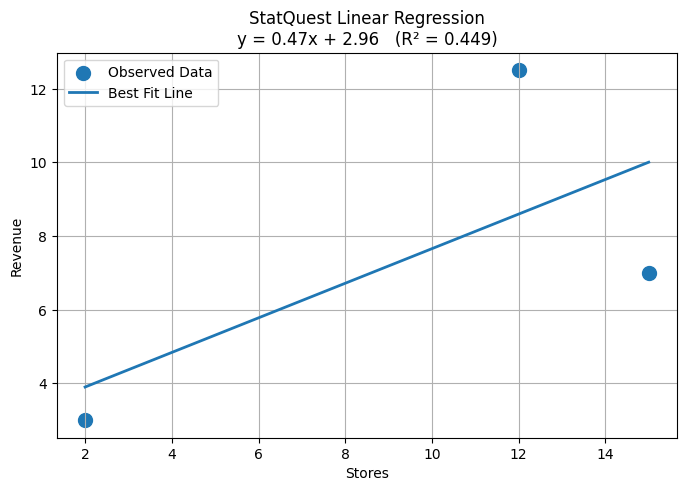

In [3]:
if __name__ == "__main__":
    stores = [2, 12, 15]
    revenue = [3, 12.5, 7]

    model = StatQuestLinearRegression()

    model.fit(stores, revenue)

    ss_mean, ssr_line, r_squared = model.calculate_metrics(
        stores,
        revenue,
    )

    p_value = model.calculate_p_value(
        stores,
        revenue,
        n_simulations=50000,
    )

    print("=== StatQuest Linear Regression Results ===")
    print(f"Optimal Intercept (b) : {model.b:.2f}")
    print(f"Optimal Slope (m)     : {model.m:.2f}")
    print(f"Line Equation         : Revenue = {model.m:.2f} * Stores + {model.b:.2f}")
    print(f"SS(mean) Baseline     : {ss_mean:.2f}")
    print(f"SSR(line) Optimized   : {ssr_line:.2f}")
    print(f"Calculated R²         : {r_squared:.2f}")
    print(f"Calculated p-value    : {p_value:.4f}")

    # Plot regression line
    model.plot(stores, revenue)

## [Ridge Regression](https://www.geeksforgeeks.org/machine-learning/what-is-ridge-regression/)

Ridge Regression is a version of linear regression that adds an L2 penalty to control large coefficient values. While Linear Regression only minimizes prediction error, it can become unstable when features are highly correlated. Ridge solves this by shrinking coefficients making the model more stable and reducing overfitting. It helps in:

*L2 Regularization:* Adds an L2 penalty to model weights
*Bias-Variance Tradeoff:* Controls how large coefficients can grow
*Multicollinearity:* Improves stability when features overlap
*Generalization:* Helps the model generalize better on new data

In [7]:
import numpy as np
import matplotlib.pyplot as plt


class StatQuestLinearRegression:
    """
    Linear Regression with optional Ridge (L2) Regularization.

    alpha = 0.0  -> Ordinary Least Squares
    alpha > 0.0  -> Ridge Regression
    """

    def __init__(self, alpha=0.0):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        x_mean = np.mean(X)
        y_mean = np.mean(y)

        numerator = np.sum((X - x_mean) * (y - y_mean))

        denominator = (
            np.sum((X - x_mean) ** 2)
            + self.alpha
        )

        self.m = 0.0 if denominator == 0 else numerator / denominator

        self.b = y_mean - self.m * x_mean

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.m * X + self.b

    def calculate_metrics(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        y_pred = self.predict(X)

        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)

        r_squared = (
            0.0
            if ss_total == 0
            else 1 - (ss_residual / ss_total)
        )

        return {
            "ss_total": ss_total,
            "ss_residual": ss_residual,
            "r_squared": r_squared,
        }
    @staticmethod
    def compare_models(X, y, alpha_values=(0, 20)):
        """
        Plot multiple regression lines on the same chart
        for comparing regularization strengths.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
    
        plt.figure(figsize=(10, 6))
    
        # Original data
        plt.scatter(
            X,
            y,
            s=100,
            label="Observed Data",
        )
    
        x_line = np.linspace(
            np.min(X),
            np.max(X),
            100,
        )
    
        for alpha in alpha_values:
            model = StatQuestLinearRegression(alpha=alpha)
            model.fit(X, y)
    
            y_line = model.predict(x_line)
    
            _, _, r2 = model.calculate_metrics(X, y).values()
    
            plt.plot(
                x_line,
                y_line,
                linewidth=2,
                label=(
                    f"alpha={alpha} | "
                    f"m={model.m:.3f} | "
                    f"R²={r2:.3f}"
                ),
            )
    
        plt.xlabel("Stores")
        plt.ylabel("Revenue")
        plt.title(
            "OLS vs Ridge Regression"
        )
        plt.grid(True)
        plt.legend()
        plt.show()
        

    def plot(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        sort_idx = np.argsort(X)

        x_line = X[sort_idx]
        y_line = self.predict(x_line)

        metrics = self.calculate_metrics(X, y)

        plt.figure(figsize=(8, 5))

        plt.scatter(X, y, s=100, label="Data")
        plt.plot(
            x_line,
            y_line,
            linewidth=2,
            label=f"alpha={self.alpha}",
        )

        plt.xlabel("X")
        plt.ylabel("y")

        plt.title(
            f"y = {self.m:.3f}x + {self.b:.3f}\n"
            f"R² = {metrics['r_squared']:.3f}"
        )

        plt.grid(True)
        plt.legend()
        plt.show()

OLS
Slope: 0.4694
Intercept: 2.9622

Ridge
Slope: 0.3861
Intercept: 3.7678


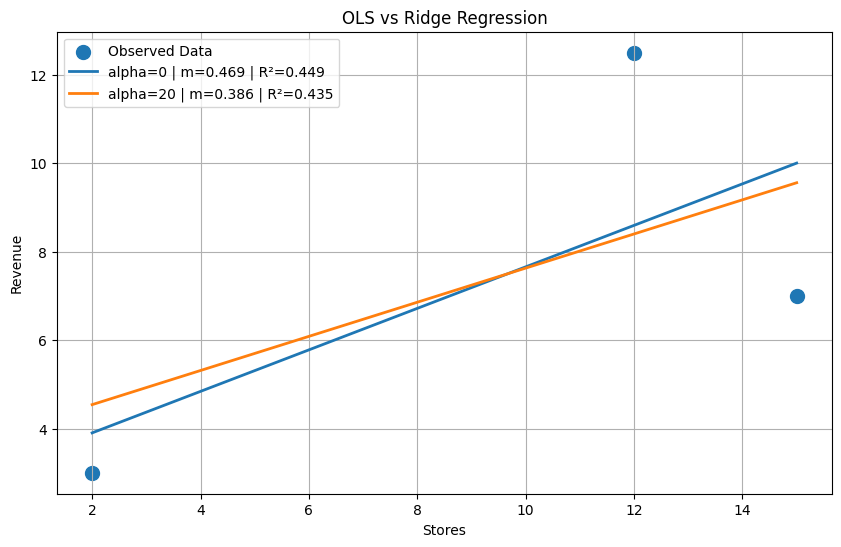

In [8]:
stores = [2, 12, 15]
revenue = [3, 12.5, 7]

ols = StatQuestLinearRegression(alpha=0)
ols.fit(stores, revenue)

ridge = StatQuestLinearRegression(alpha=20)
ridge.fit(stores, revenue)

print("OLS")
print(f"Slope: {ols.m:.4f}")
print(f"Intercept: {ols.b:.4f}")

print("\nRidge")
print(f"Slope: {ridge.m:.4f}")
print(f"Intercept: {ridge.b:.4f}")

StatQuestLinearRegression.compare_models(
    stores,
    revenue,
    alpha_values=[0, 20],
)